In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from datetime import datetime

In [3]:
file_name = "./data/full_bus_data_high_confidence.csv"

bus_data = pd.read_csv(file_name)

/var/folders/xt/5my4_t657l5dvcsk9ybkb_ww0000gn/T/ipykernel_54664/2233828969.py:3: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  bus_data = pd.read_csv(file_name)


In [4]:
bus_data["10_min_time"] = pd.to_datetime(bus_data["Time"])
bus_data["10_min_time"] = bus_data["10_min_time"].dt.floor("10T")
bus_data_copy = bus_data

# drop outliers (display these later)
super_delays = bus_data[bus_data["Min Delay"]>60].dropna()
super_delays = super_delays[super_delays["Min Delay"]<1000]
bus_data = bus_data[bus_data["Min Delay"]<=60] 

mean_bus_data = bus_data.groupby("10_min_time")[["Min Delay", "Min Gap"]].mean().reset_index()
super_means = super_delays.groupby("10_min_time")[["Min Delay", "Min Gap"]].mean().reset_index()

display(mean_bus_data)

/var/folders/xt/5my4_t657l5dvcsk9ybkb_ww0000gn/T/ipykernel_54664/3461497850.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  bus_data["10_min_time"] = pd.to_datetime(bus_data["Time"])
/var/folders/xt/5my4_t657l5dvcsk9ybkb_ww0000gn/T/ipykernel_54664/3461497850.py:2: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  bus_data["10_min_time"] = bus_data["10_min_time"].dt.floor("10T")


,10_min_time,Min Delay,Min Gap
0,2025-04-03 00:00:00,15.418692,30.037418
1,2025-04-03 00:10:00,14.882917,29.673704
2,2025-04-03 00:20:00,15.044955,29.124875
3,2025-04-03 00:30:00,15.091667,29.300000
4,2025-04-03 00:40:00,14.816504,28.552660
...,...,...,...
139,2025-04-03 23:10:00,15.497031,30.128075
140,2025-04-03 23:20:00,15.080895,29.577453
141,2025-04-03 23:30:00,15.220366,29.930788
142,2025-04-03 23:40:00,15.204789,29.229562


In [5]:
time = mean_bus_data["10_min_time"].dt.strftime("%I:%M %p")
time_ticks  = time[::12]
delay = mean_bus_data["Min Delay"]
gap = mean_bus_data["Min Gap"]
super_time = super_means["10_min_time"].dt.strftime("%I:%M %p")
super_delay = super_means["Min Delay"]
super_gap = super_means["Min Gap"]

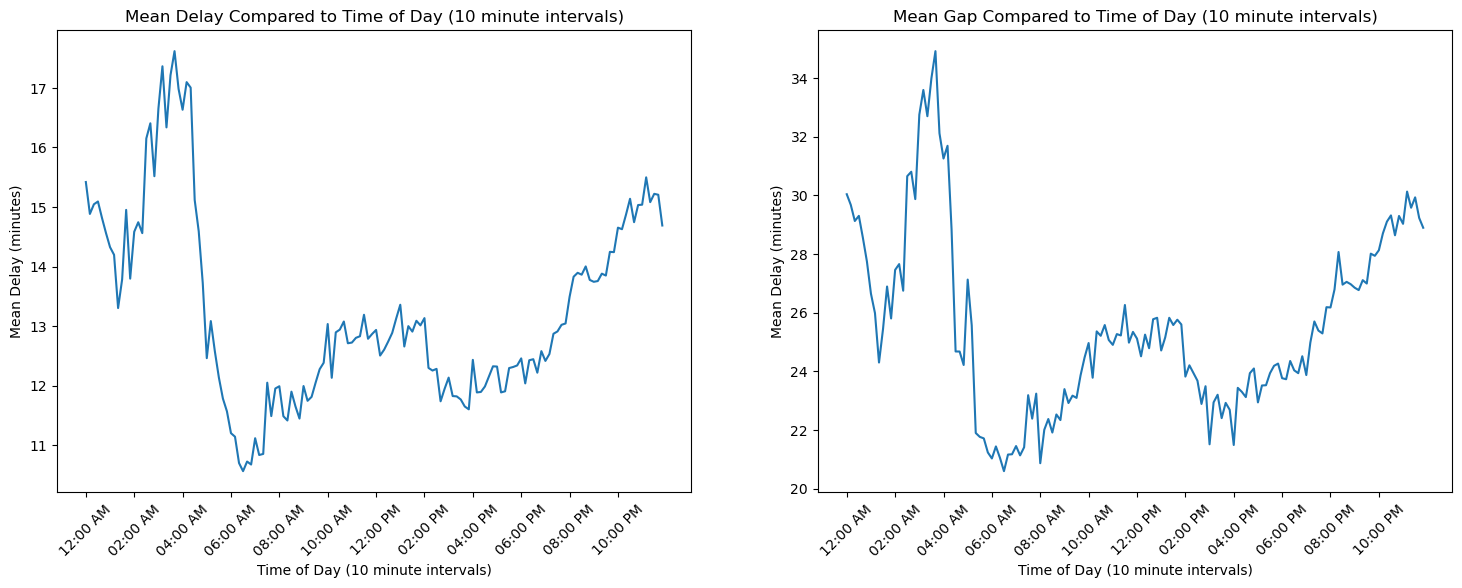

In [6]:
fig, axes = plt.subplots(1, 2, figsize = (18, 6))

axes[0].plot(time, delay, linestyle='-')
axes[0].set_title("Mean Delay Compared to Time of Day (10 minute intervals)")
axes[0].set_xlabel("Time of Day (10 minute intervals)")
axes[0].set_ylabel("Mean Delay (minutes)")
axes[0].set_xticks(time_ticks)
axes[0].tick_params(axis='x', rotation=45)

axes[1].plot(time, gap, linestyle='-')
axes[1].set_title("Mean Gap Compared to Time of Day (10 minute intervals)")
axes[1].set_xlabel("Time of Day (10 minute intervals)")
axes[1].set_ylabel("Mean Delay (minutes)")
axes[1].set_xticks(time_ticks)
axes[1].tick_params(axis='x', rotation=45)

## Analysis for super delays (>60 mins)

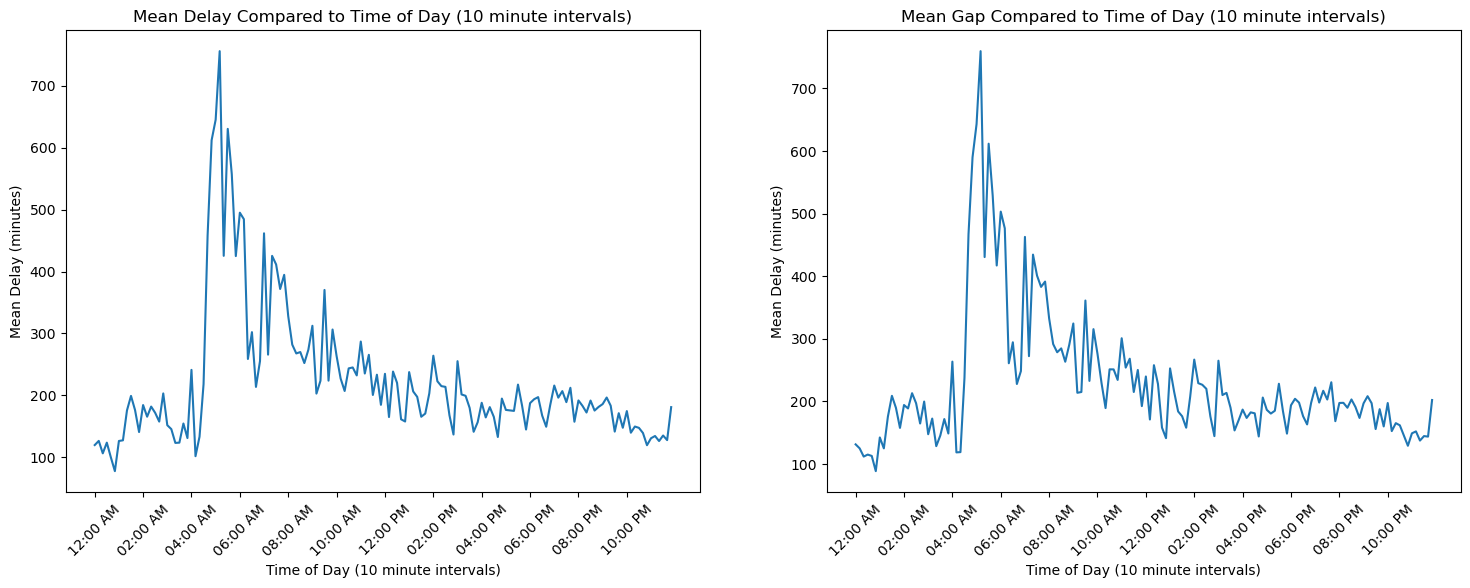

In [7]:
fig, axes = plt.subplots(1, 2, figsize = (18, 6))

axes[0].plot(super_time, super_delay, linestyle='-')
axes[0].set_title("Mean Delay Compared to Time of Day (10 minute intervals)")
axes[0].set_xlabel("Time of Day (10 minute intervals)")
axes[0].set_ylabel("Mean Delay (minutes)")
axes[0].set_xticks(time_ticks)
axes[0].tick_params(axis='x', rotation=45)

axes[1].plot(super_time, super_gap, linestyle='-')
axes[1].set_title("Mean Gap Compared to Time of Day (10 minute intervals)")
axes[1].set_xlabel("Time of Day (10 minute intervals)")
axes[1].set_ylabel("Mean Delay (minutes)")
axes[1].set_xticks(time_ticks)
axes[1].tick_params(axis='x', rotation=45)

## Without removing outliers

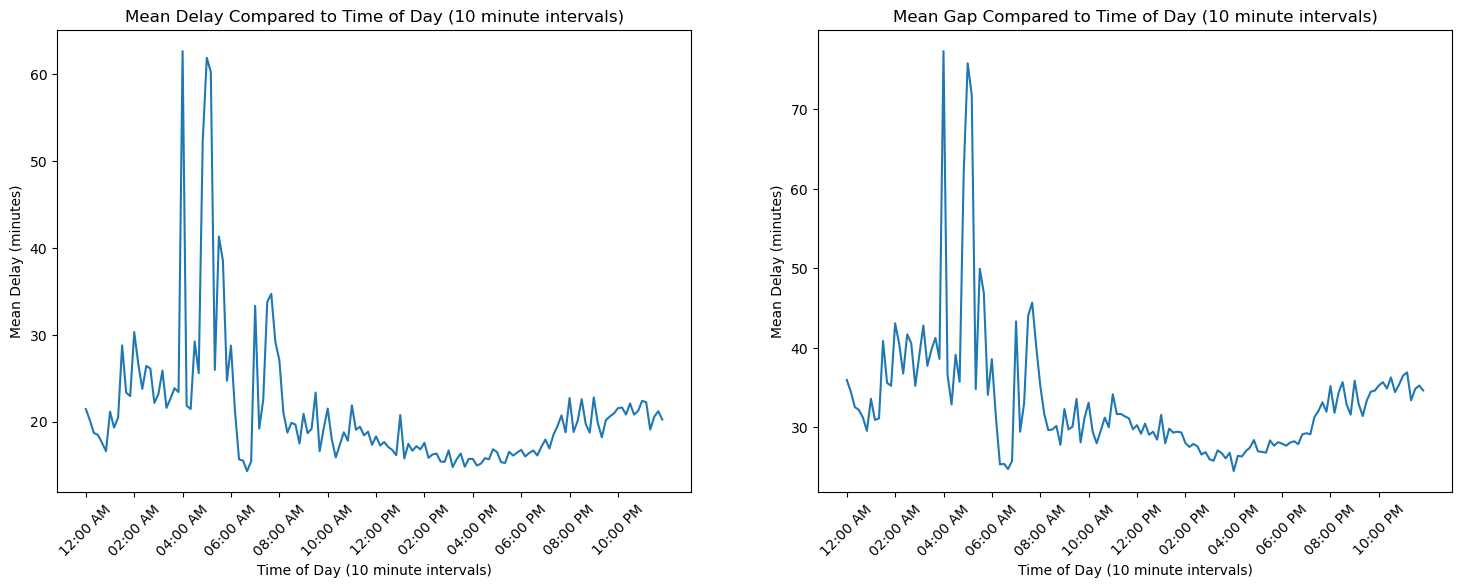

In [8]:
mean_bus_data = bus_data_copy.groupby("10_min_time")[["Min Delay", "Min Gap"]].mean().reset_index()
time = mean_bus_data["10_min_time"].dt.strftime("%I:%M %p")
time_ticks  = time[::12]
delay = mean_bus_data["Min Delay"]
gap = mean_bus_data["Min Gap"]

fig, axes = plt.subplots(1, 2, figsize = (18, 6))

axes[0].plot(time, delay, linestyle='-')
axes[0].set_title("Mean Delay Compared to Time of Day (10 minute intervals)")
axes[0].set_xlabel("Time of Day (10 minute intervals)")
axes[0].set_ylabel("Mean Delay (minutes)")
axes[0].set_xticks(time_ticks)
axes[0].tick_params(axis='x', rotation=45)

axes[1].plot(time, gap, linestyle='-')
axes[1].set_title("Mean Gap Compared to Time of Day (10 minute intervals)")
axes[1].set_xlabel("Time of Day (10 minute intervals)")
axes[1].set_ylabel("Mean Delay (minutes)")
axes[1].set_xticks(time_ticks)
axes[1].tick_params(axis='x', rotation=45)

## By day of the week

,Day,Min Delay,Min Gap
1,Monday,12.353572,23.831244
5,Tuesday,12.164068,23.457769
6,Wednesday,12.134499,23.443425
4,Thursday,12.188358,23.381693
0,Friday,12.265754,23.769938
2,Saturday,13.408536,25.998885
3,Sunday,14.025152,27.198465


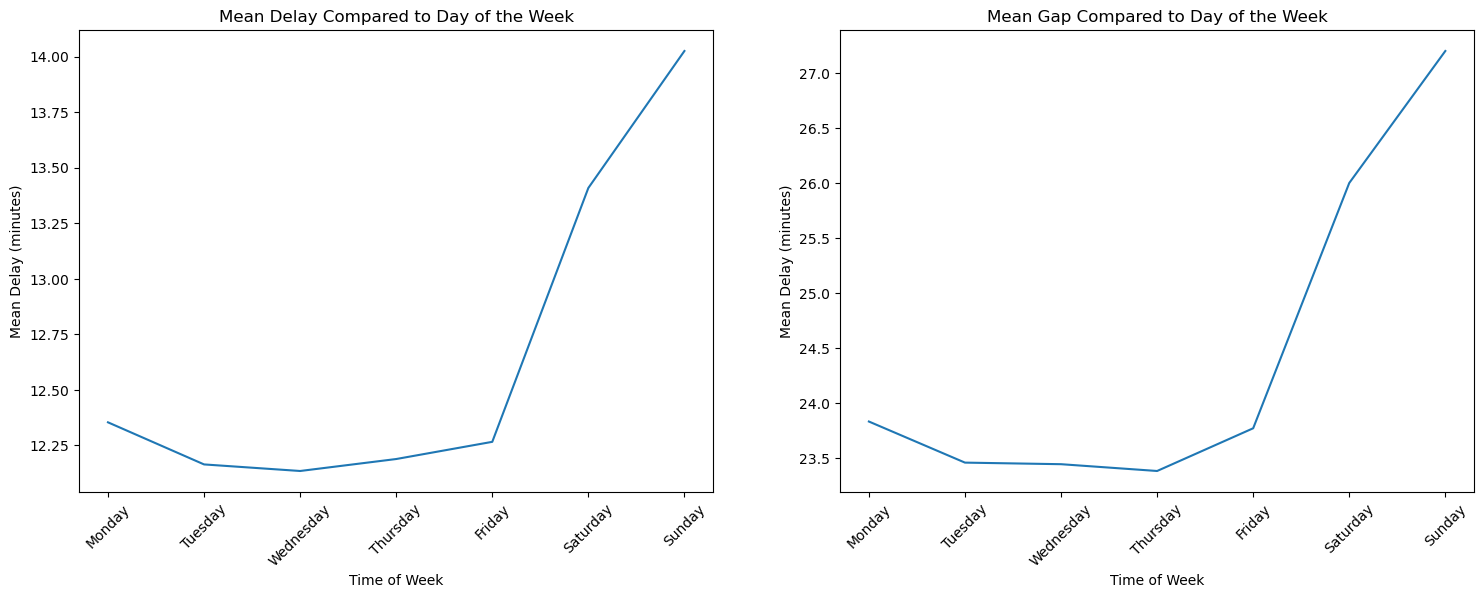

In [9]:
new_data  = bus_data_copy[bus_data_copy["Min Delay"]<=60]

mean_bus_data = new_data.groupby("Day")[["Min Delay", "Min Gap"]].mean().reset_index()
mean_bus_data = mean_bus_data.reindex([1, 5, 6, 4, 0, 2, 3])
time = mean_bus_data["Day"]
delay = mean_bus_data["Min Delay"]
gap = mean_bus_data["Min Gap"]

display(mean_bus_data)

fig, axes = plt.subplots(1, 2, figsize = (18, 6))

axes[0].plot(time, delay, linestyle='-')
axes[0].set_title("Mean Delay Compared to Day of the Week")
axes[0].set_xlabel("Time of Week")
axes[0].set_ylabel("Mean Delay (minutes)")
axes[0].tick_params(axis='x', rotation=45)

axes[1].plot(time, gap, linestyle='-')
axes[1].set_title("Mean Gap Compared to Day of the Week")
axes[1].set_xlabel("Time of Week")
axes[1].set_ylabel("Mean Delay (minutes)")
axes[1].tick_params(axis='x', rotation=45)

,Day,Min Delay,Min Gap
1,Monday,273.464470,279.113049
5,Tuesday,257.030715,264.185579
6,Wednesday,262.481121,268.137300
4,Thursday,260.087091,268.087091
0,Friday,260.785950,266.757409
2,Saturday,279.999371,284.262429
3,Sunday,259.534646,267.849745


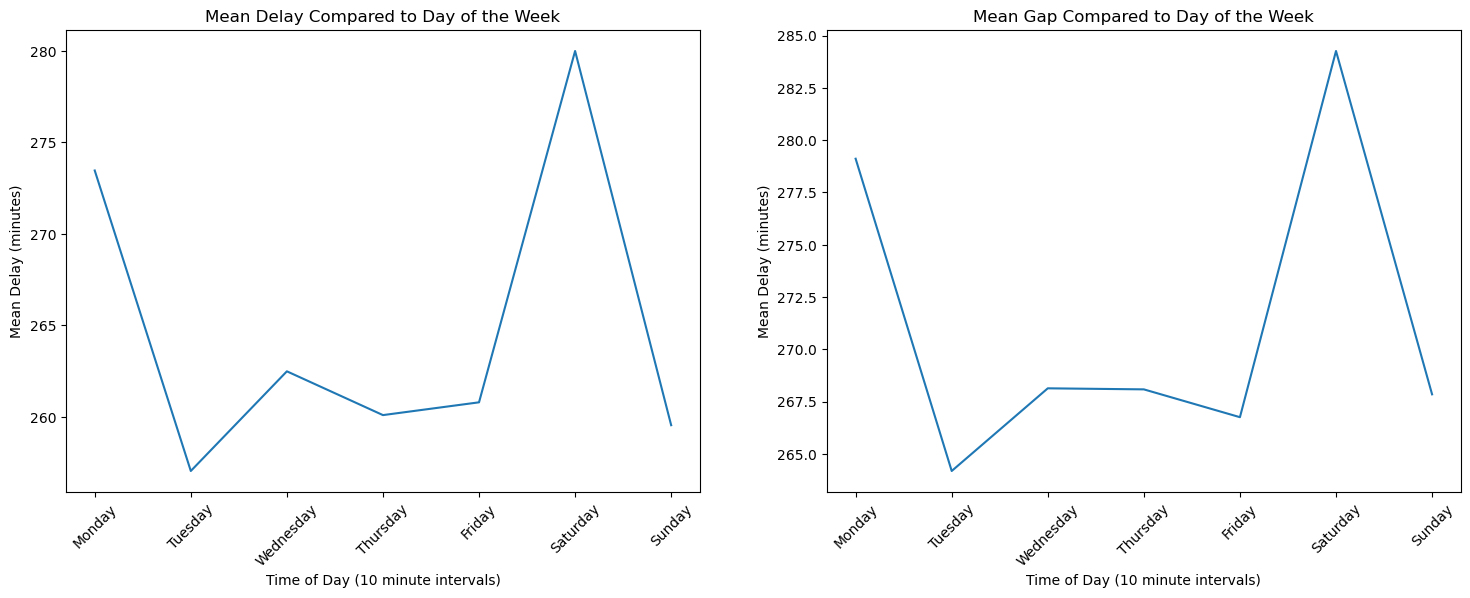

In [10]:
new_data  = bus_data_copy[bus_data_copy["Min Delay"]>60]

mean_bus_data = new_data.groupby("Day")[["Min Delay", "Min Gap"]].mean().reset_index()
mean_bus_data = mean_bus_data.reindex([1, 5, 6, 4, 0, 2, 3])
time = mean_bus_data["Day"]
delay = mean_bus_data["Min Delay"]
gap = mean_bus_data["Min Gap"]

display(mean_bus_data)

fig, axes = plt.subplots(1, 2, figsize = (18, 6))

axes[0].plot(time, delay, linestyle='-')
axes[0].set_title("Mean Delay Compared to Day of the Week")
axes[0].set_xlabel("Time of Day (10 minute intervals)")
axes[0].set_ylabel("Mean Delay (minutes)")
axes[0].tick_params(axis='x', rotation=45)

axes[1].plot(time, gap, linestyle='-')
axes[1].set_title("Mean Gap Compared to Day of the Week")
axes[1].set_xlabel("Time of Day (10 minute intervals)")
axes[1].set_ylabel("Mean Delay (minutes)")
axes[1].tick_params(axis='x', rotation=45)

## Analysis by Day of Week and Time

In [11]:
bus_data = pd.read_csv(file_name)

bus_data["10_min_time"] = pd.to_datetime(bus_data["Time"])
bus_data["10_min_time"] = bus_data["10_min_time"].dt.floor("10T")
bus_data_copy = bus_data

# drop outliers (display these later)
super_delays = bus_data[bus_data["Min Delay"]>60].dropna()
super_delays = super_delays[super_delays["Min Delay"]<1000]
bus_data = bus_data[bus_data["Min Delay"]<=60] 

mean_bus_data = bus_data.groupby(["Day","10_min_time"])[["Min Delay", "Min Gap"]].mean().reset_index()
super_means = super_delays.groupby(["Day","10_min_time"])[["Min Delay", "Min Gap"]].mean().reset_index()

display(mean_bus_data)

/var/folders/xt/5my4_t657l5dvcsk9ybkb_ww0000gn/T/ipykernel_54664/493537520.py:1: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  bus_data = pd.read_csv(file_name)
/var/folders/xt/5my4_t657l5dvcsk9ybkb_ww0000gn/T/ipykernel_54664/493537520.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  bus_data["10_min_time"] = pd.to_datetime(bus_data["Time"])
/var/folders/xt/5my4_t657l5dvcsk9ybkb_ww0000gn/T/ipykernel_54664/493537520.py:4: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  bus_data["10_min_time"] = bus_data["10_min_time"].dt.floor("10T")


,Day,10_min_time,Min Delay,Min Gap
0,Friday,2025-04-03 00:00:00,14.942529,29.626437
1,Friday,2025-04-03 00:10:00,15.506579,30.394737
2,Friday,2025-04-03 00:20:00,15.242604,28.710059
3,Friday,2025-04-03 00:30:00,15.787709,31.178771
4,Friday,2025-04-03 00:40:00,15.317460,28.428571
...,...,...,...,...
1003,Wednesday,2025-04-03 23:10:00,15.562842,29.934426
1004,Wednesday,2025-04-03 23:20:00,14.374194,28.748387
1005,Wednesday,2025-04-03 23:30:00,15.301282,29.974359
1006,Wednesday,2025-04-03 23:40:00,14.885714,27.645714


In [12]:
delay = {}
time = {}
gap = {}
for day in ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]:
    time[day] = mean_bus_data.loc[mean_bus_data["Day"] == day]["10_min_time"].dt.strftime("%I:%M %p")
    delay[day] = mean_bus_data.loc[mean_bus_data["Day"] == day]["Min Delay"].values
    gap[day] = mean_bus_data.loc[mean_bus_data["Day"] == day]["Min Gap"].values
time_ticks = time["Monday"][::12]
super_time = super_means["10_min_time"].dt.strftime("%I:%M %p")
super_delay = super_means["Min Delay"]
super_gap = super_means["Min Gap"]

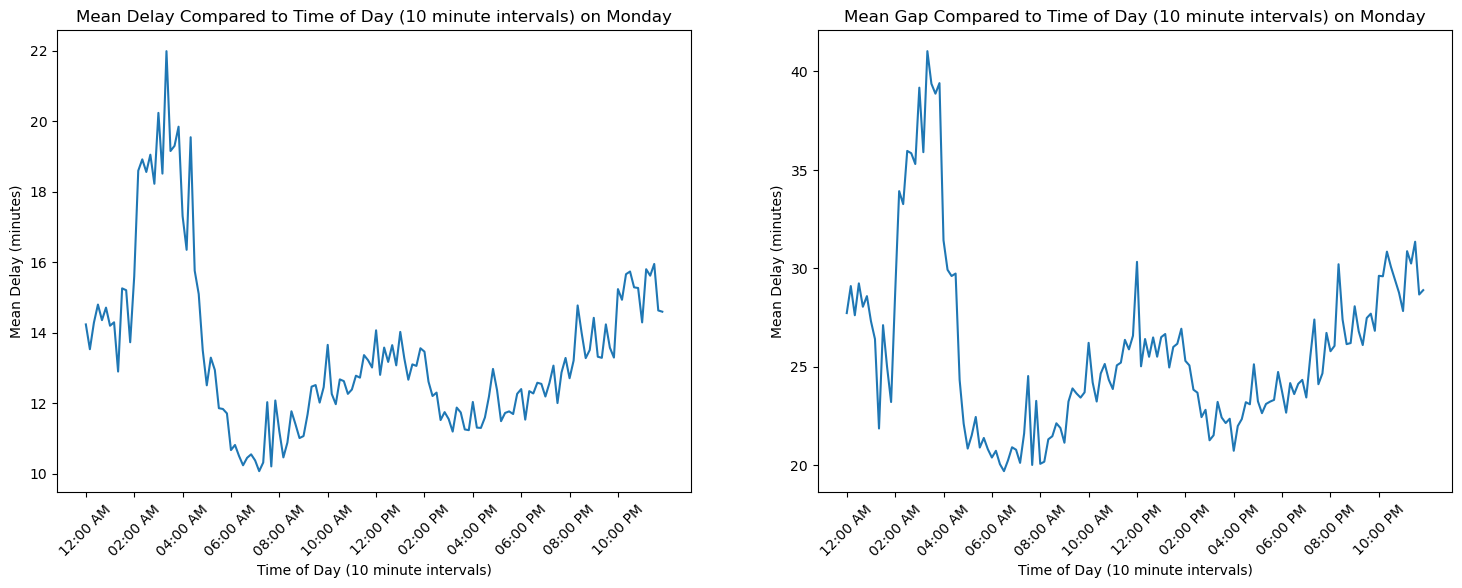

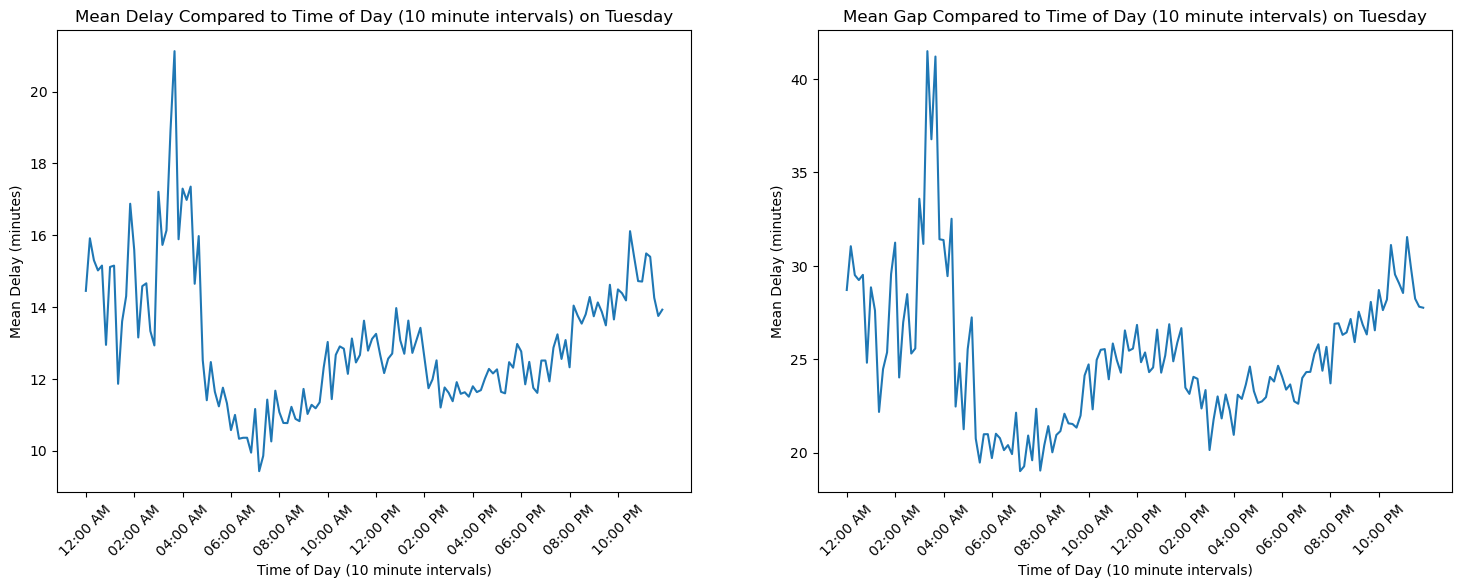

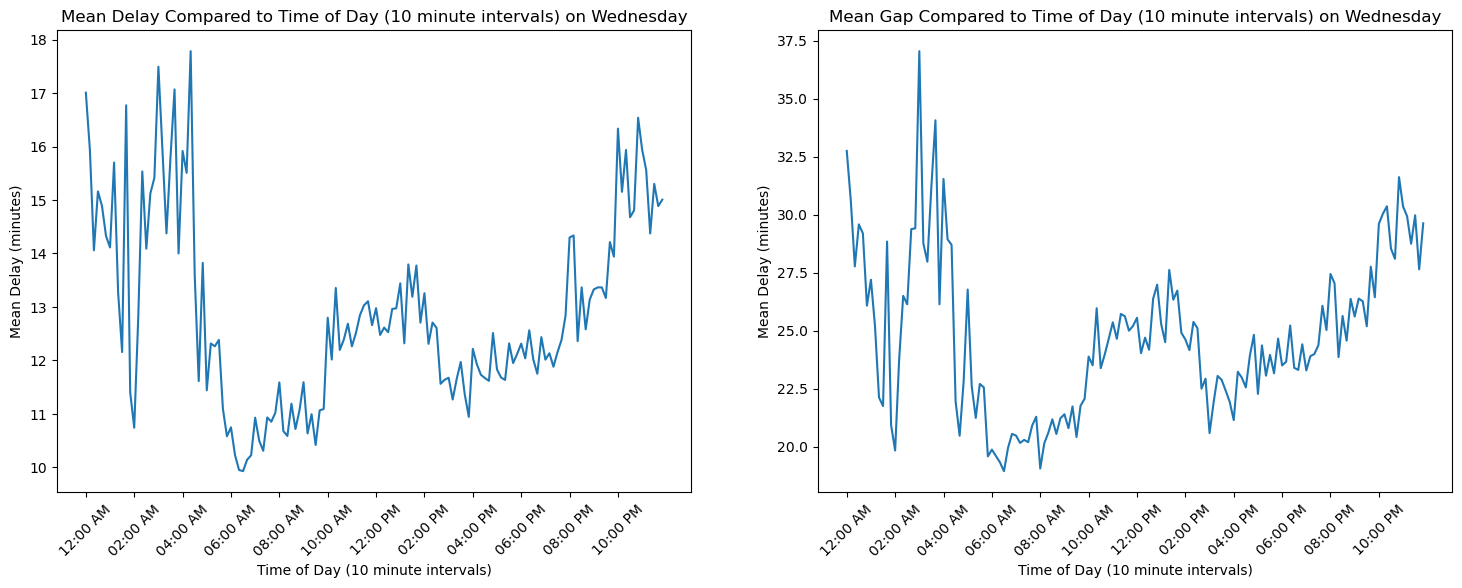

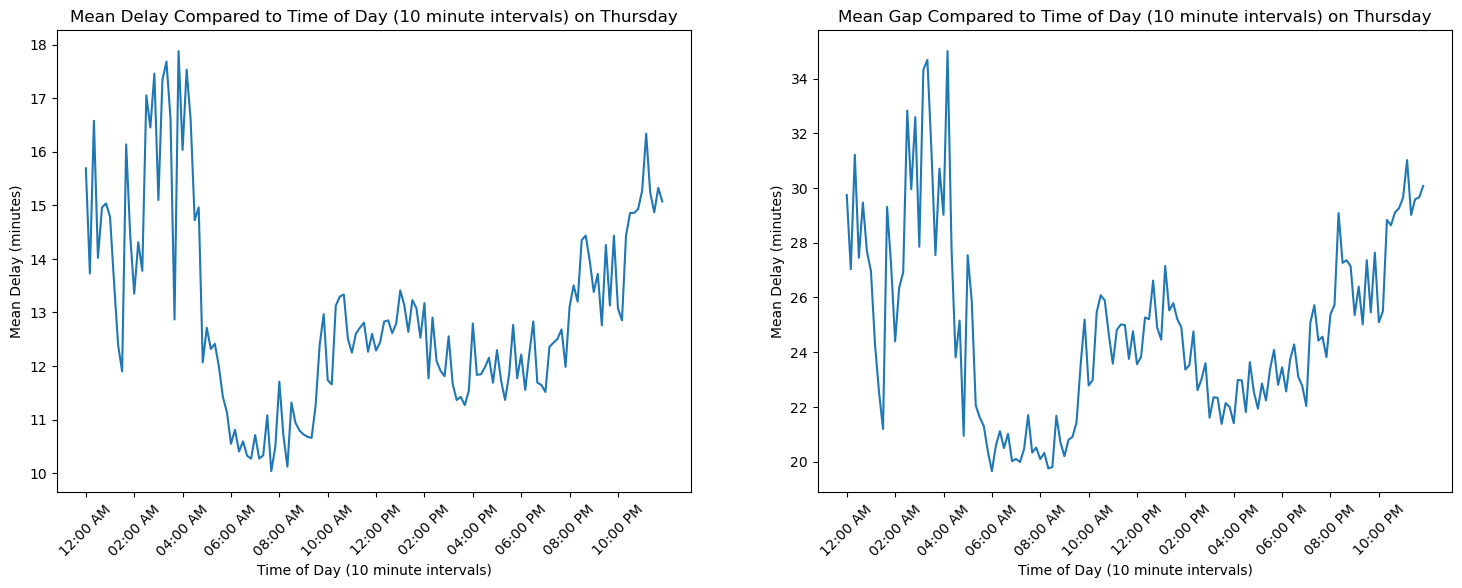

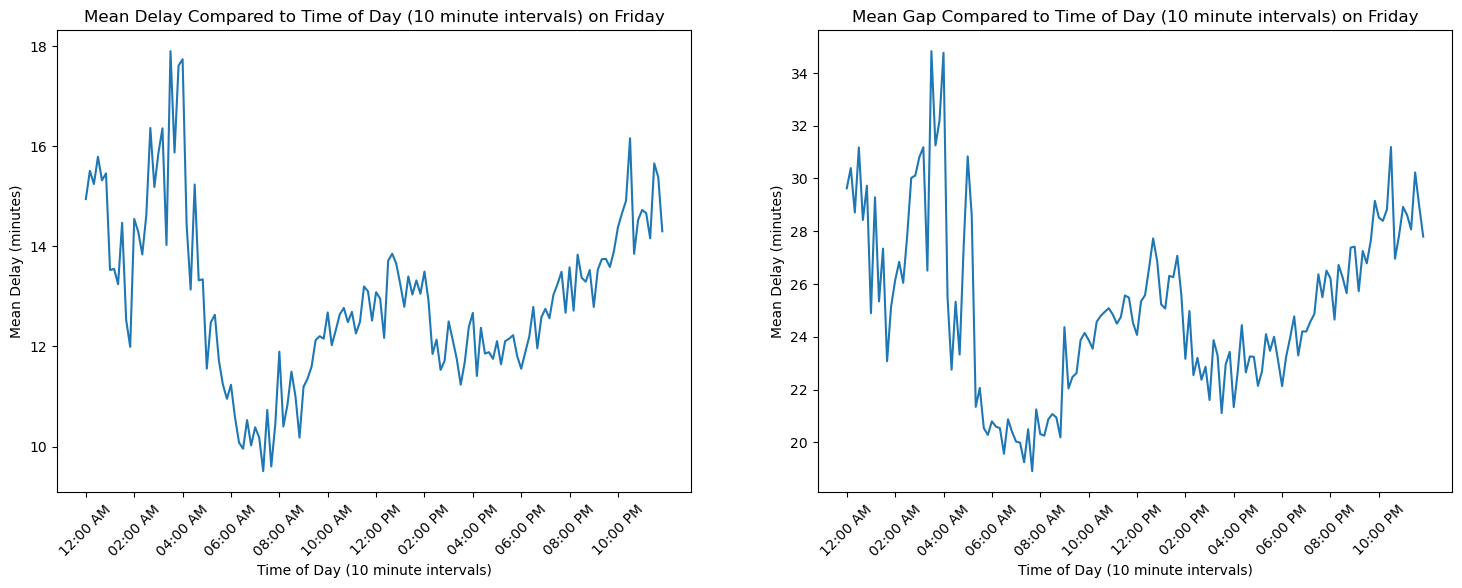

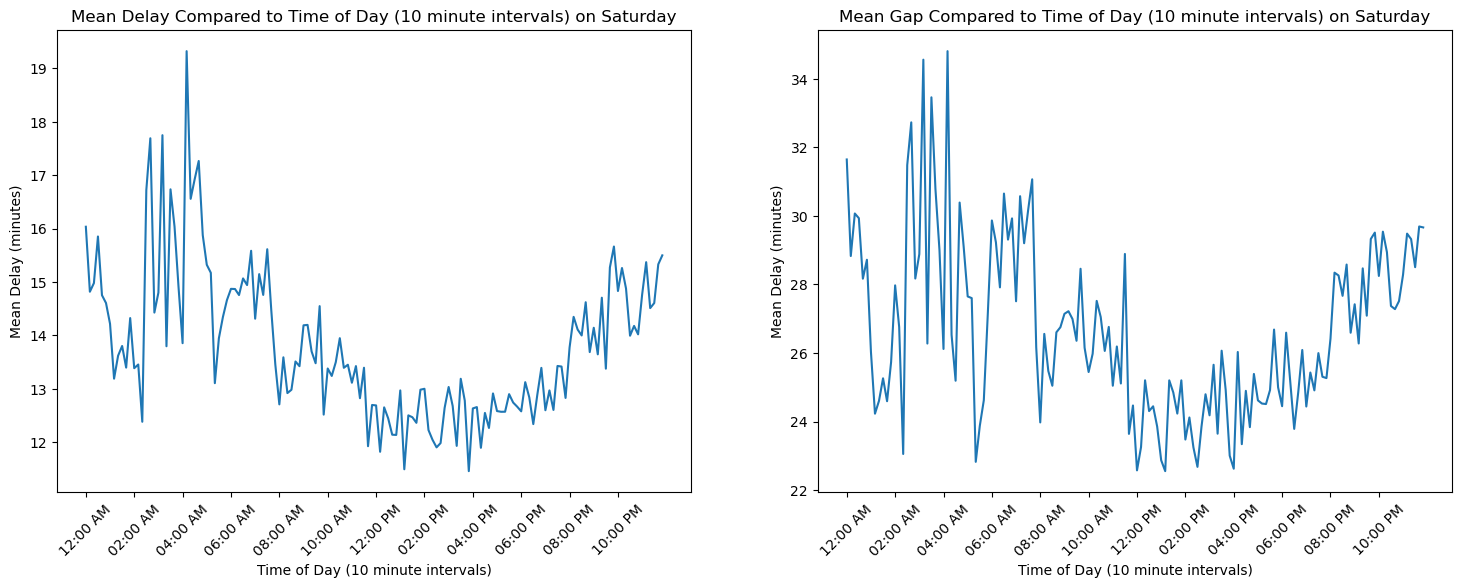

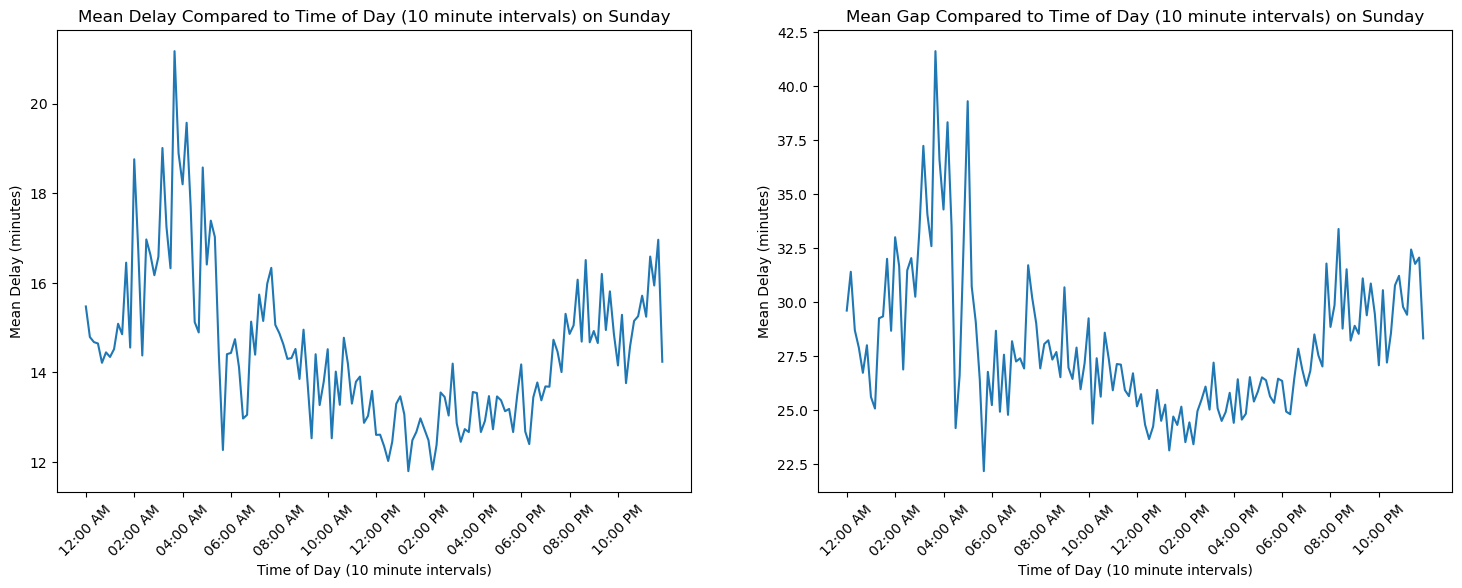

In [13]:
for day in ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]:
    fig, axes = plt.subplots(1, 2, figsize = (18, 6))

    axes[0].set_title(f"Mean Delay Compared to Time of Day (10 minute intervals) on {day}")
    axes[0].set_xlabel("Time of Day (10 minute intervals)")
    axes[0].set_ylabel("Mean Delay (minutes)")
    axes[0].plot(time[day], delay[day], linestyle='-')
    axes[0].set_xticks(time_ticks)
    axes[0].tick_params(axis='x', rotation=45)

    axes[1].plot(time[day], gap[day], linestyle='-')
    axes[1].set_title(f"Mean Gap Compared to Time of Day (10 minute intervals) on {day}")
    axes[1].set_xlabel("Time of Day (10 minute intervals)")
    axes[1].set_ylabel("Mean Delay (minutes)")
    axes[1].set_xticks(time_ticks)
    axes[1].tick_params(axis='x', rotation=45)
    plt.savefig(f"./data/time_delays_{day}.png")
    plt.show()

In [14]:
bus_data = bus_data_copy
dates = bus_data["DateTime"]
bus_data["30_day"] = pd.to_datetime(bus_data["DateTime"])
bus_data["30_day"] = bus_data["30_day"].dt.floor("30D")
bus_data = bus_data[bus_data["Min Delay"]<=60] 
bus_data = bus_data[bus_data["30_day"]<=pd.Timestamp("2025-01-01")] 

mean_bus_data = bus_data.groupby("30_day")[["Min Delay", "Min Gap"]].mean().reset_index()
count_bus_data = bus_data.groupby("30_day")[["Min Delay", "Min Gap"]].count().reset_index()


In [15]:
time = mean_bus_data["30_day"]
time_ticks  = time[::12]
delay = mean_bus_data["Min Delay"]
gap = mean_bus_data["Min Gap"]

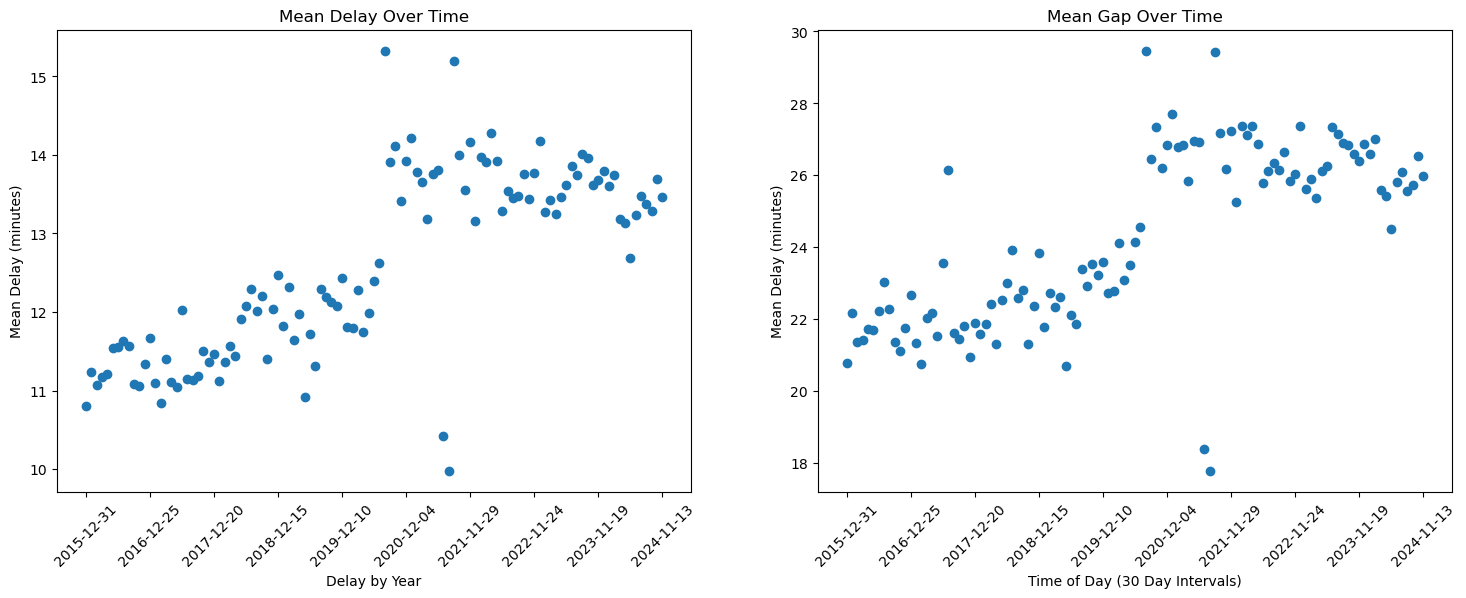

In [16]:
fig, axes = plt.subplots(1, 2, figsize = (18, 6))

axes[0].scatter(time, delay, marker='o')
axes[0].set_title("Mean Delay Over Time")
axes[0].set_xlabel("Delay by Year")
axes[0].set_ylabel("Mean Delay (minutes)")
axes[0].set_xticks(time_ticks)
axes[0].tick_params(axis='x', rotation=45)

axes[1].scatter(time, gap,  marker='o')
axes[1].set_title("Mean Gap Over Time")
axes[1].set_xlabel("Time of Day (30 Day Intervals)")
axes[1].set_ylabel("Mean Delay (minutes)")
axes[1].set_xticks(time_ticks)
axes[1].tick_params(axis='x', rotation=45)

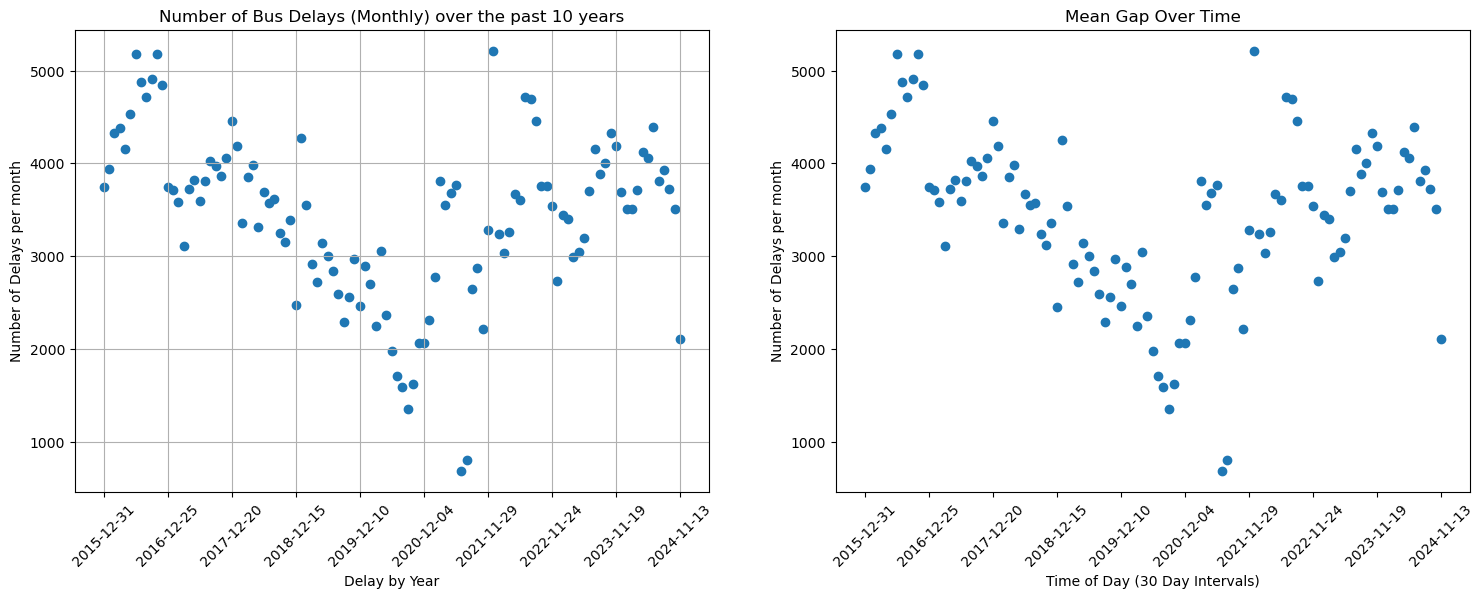

In [ ]:
count_bus_data = bus_data.groupby("30_day")[["Min Delay", "Min Gap"]].count().reset_index()

time = count_bus_data["30_day"]
time_ticks  = time[::12]
delay = count_bus_data["Min Delay"]
gap = count_bus_data["Min Gap"]

fig, axes = plt.subplots(1, 2, figsize = (18, 6))

axes[0].scatter(time, delay, marker='o')
axes[0].set_title("Number of Bus Delays (Monthly) over the past 10 years")
axes[0].set_xlabel("Delay by Year")
axes[0].set_ylabel("Number of Delays per month")
axes[0].set_xticks(time_ticks)
axes[0].grid()
axes[0].tick_params(axis='x', rotation=45)

axes[1].scatter(time, gap,  marker='o')
axes[1].set_title("Mean Gap Over Time")
axes[1].set_xlabel("Time of Day (30 Day Intervals)")
axes[1].set_ylabel("Number of Delays per month")
axes[1].set_xticks(time_ticks)
axes[1].tick_params(axis='x', rotation=45)

---

Update from Cindy
Created: Mar 7, 2025 
# Delay Reasons Histogram

In [18]:
bus_data = pd.read_csv(file_name)
print(bus_data.columns)

Index(['DateTime', 'Report Date', 'Route', 'Time', 'Day', 'Location',
       'Incident', 'Min Delay', 'Min Gap', 'Direction', 'Vehicle', 'good_name',
       'confidence', 'stop_lat', 'stop_lon'],
      dtype='object')


/var/folders/xt/5my4_t657l5dvcsk9ybkb_ww0000gn/T/ipykernel_54664/2814459524.py:1: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  bus_data = pd.read_csv(file_name)


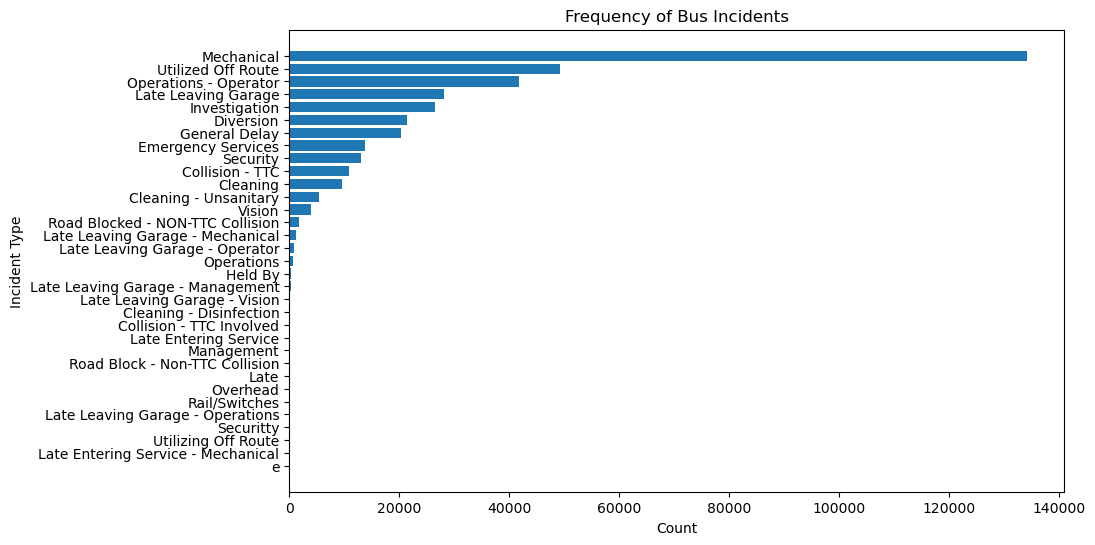

In [19]:
# Count occurrences of each incident type
incident_counts = bus_data['Incident'].value_counts()

# Plot histogram (bar chart) with incidents on y-axis and count on x-axis
plt.figure(figsize=(10, 6))
plt.barh(incident_counts.index, incident_counts.values)
plt.xlabel("Count")
plt.ylabel("Incident Type")
plt.title("Frequency of Bus Incidents")
plt.gca().invert_yaxis()  # Invert y-axis for better readability
plt.show()

In [20]:
incident_counts = bus_data['Incident'].value_counts().reset_index()

# Rename columns
incident_counts.columns = ['Incident Type', 'Count']

# Display the dataframe
print(incident_counts)

                         Incident Type   Count
0                           Mechanical  134244
1                   Utilized Off Route   49207
2                Operations - Operator   41846
3                  Late Leaving Garage   28208
4                        Investigation   26594
5                            Diversion   21489
6                        General Delay   20355
7                   Emergency Services   13728
8                             Security   13064
9                      Collision - TTC   10821
10                            Cleaning    9685
11               Cleaning - Unsanitary    5432
12                              Vision    4003
13    Road Blocked - NON-TTC Collision    1876
14    Late Leaving Garage - Mechanical    1293
15      Late Leaving Garage - Operator     960
16                          Operations     725
17                             Held By     398
18    Late Leaving Garage - Management     297
19        Late Leaving Garage - Vision     104
20           

Further data cleaning: 
1. Merge all Late Leaving Garage 
2. remove "e"
3. Merge Late entering service 
4. Merge Cleaning 
5. Merge Operations 
6. Securitty -> Typo. Directly fix 
7. Merge Road Block - Non-TTC Collision with Road Blocked 


### Data Cleaning - Incident 

In [21]:
def merge_names(name):
    name = str(name)

    if 'Late Leaving Garage' in name:
        return 'Late Leaving Garage'
    elif 'Late Entering Service' in name:
        return 'Late Entering Service'
    elif 'Cleaning' in name:
        return 'Cleaning'
    elif name == 'Securitty':
        return 'Security'
    elif 'Road Block' in name:
        return 'Road Blocked'
    else:
        return name
    
bus_data['Incident'] = bus_data['Incident'].apply(merge_names)
bus_data = bus_data[bus_data['Incident'] != 'e']
    

In [22]:
bus_data['Incident'].value_counts()

Incident
Mechanical                  134244
Utilized Off Route           49207
Operations - Operator        41846
Late Leaving Garage          30866
Investigation                26594
Diversion                    21489
General Delay                20355
Cleaning                     15192
Emergency Services           13728
Security                     13067
Collision - TTC              10821
Vision                        4003
Road Blocked                  1907
Operations                     725
nan                            455
Held By                        398
Collision - TTC Involved        60
Late Entering Service           48
Management                      40
Late                            13
Overhead                        11
Rail/Switches                    5
Utilizing Off Route              2
Name: count, dtype: int64

### Cleaned Incident bus data

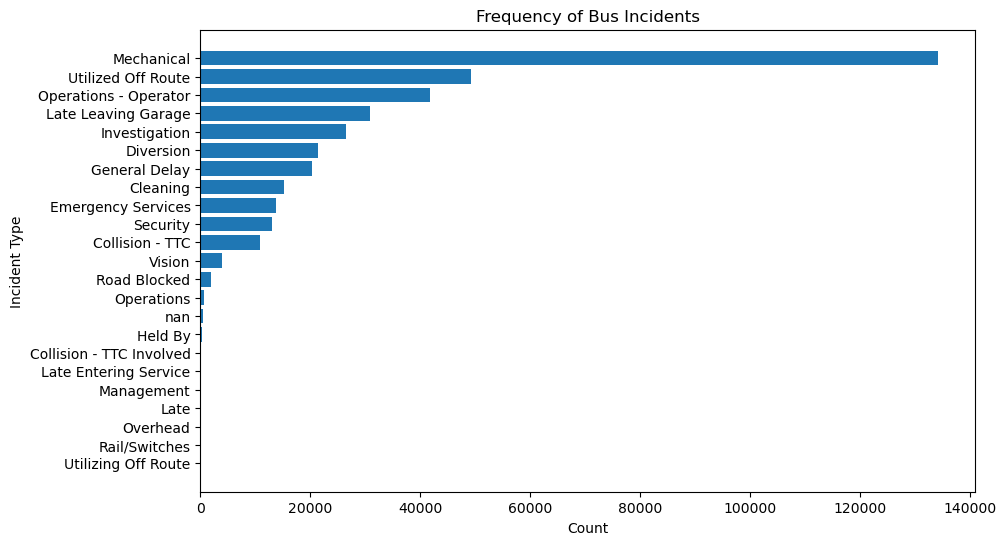

In [23]:
# Count occurrences of each incident type
incident_counts = bus_data['Incident'].value_counts()

# Plot histogram (bar chart) with incidents on y-axis and count on x-axis
plt.figure(figsize=(10, 6))
plt.barh(incident_counts.index, incident_counts.values)
plt.xlabel("Count")
plt.ylabel("Incident Type")
plt.title("Frequency of Bus Incidents")
plt.gca().invert_yaxis()  # Invert y-axis for better readability
plt.show()

---

# Delay data by weekdays 

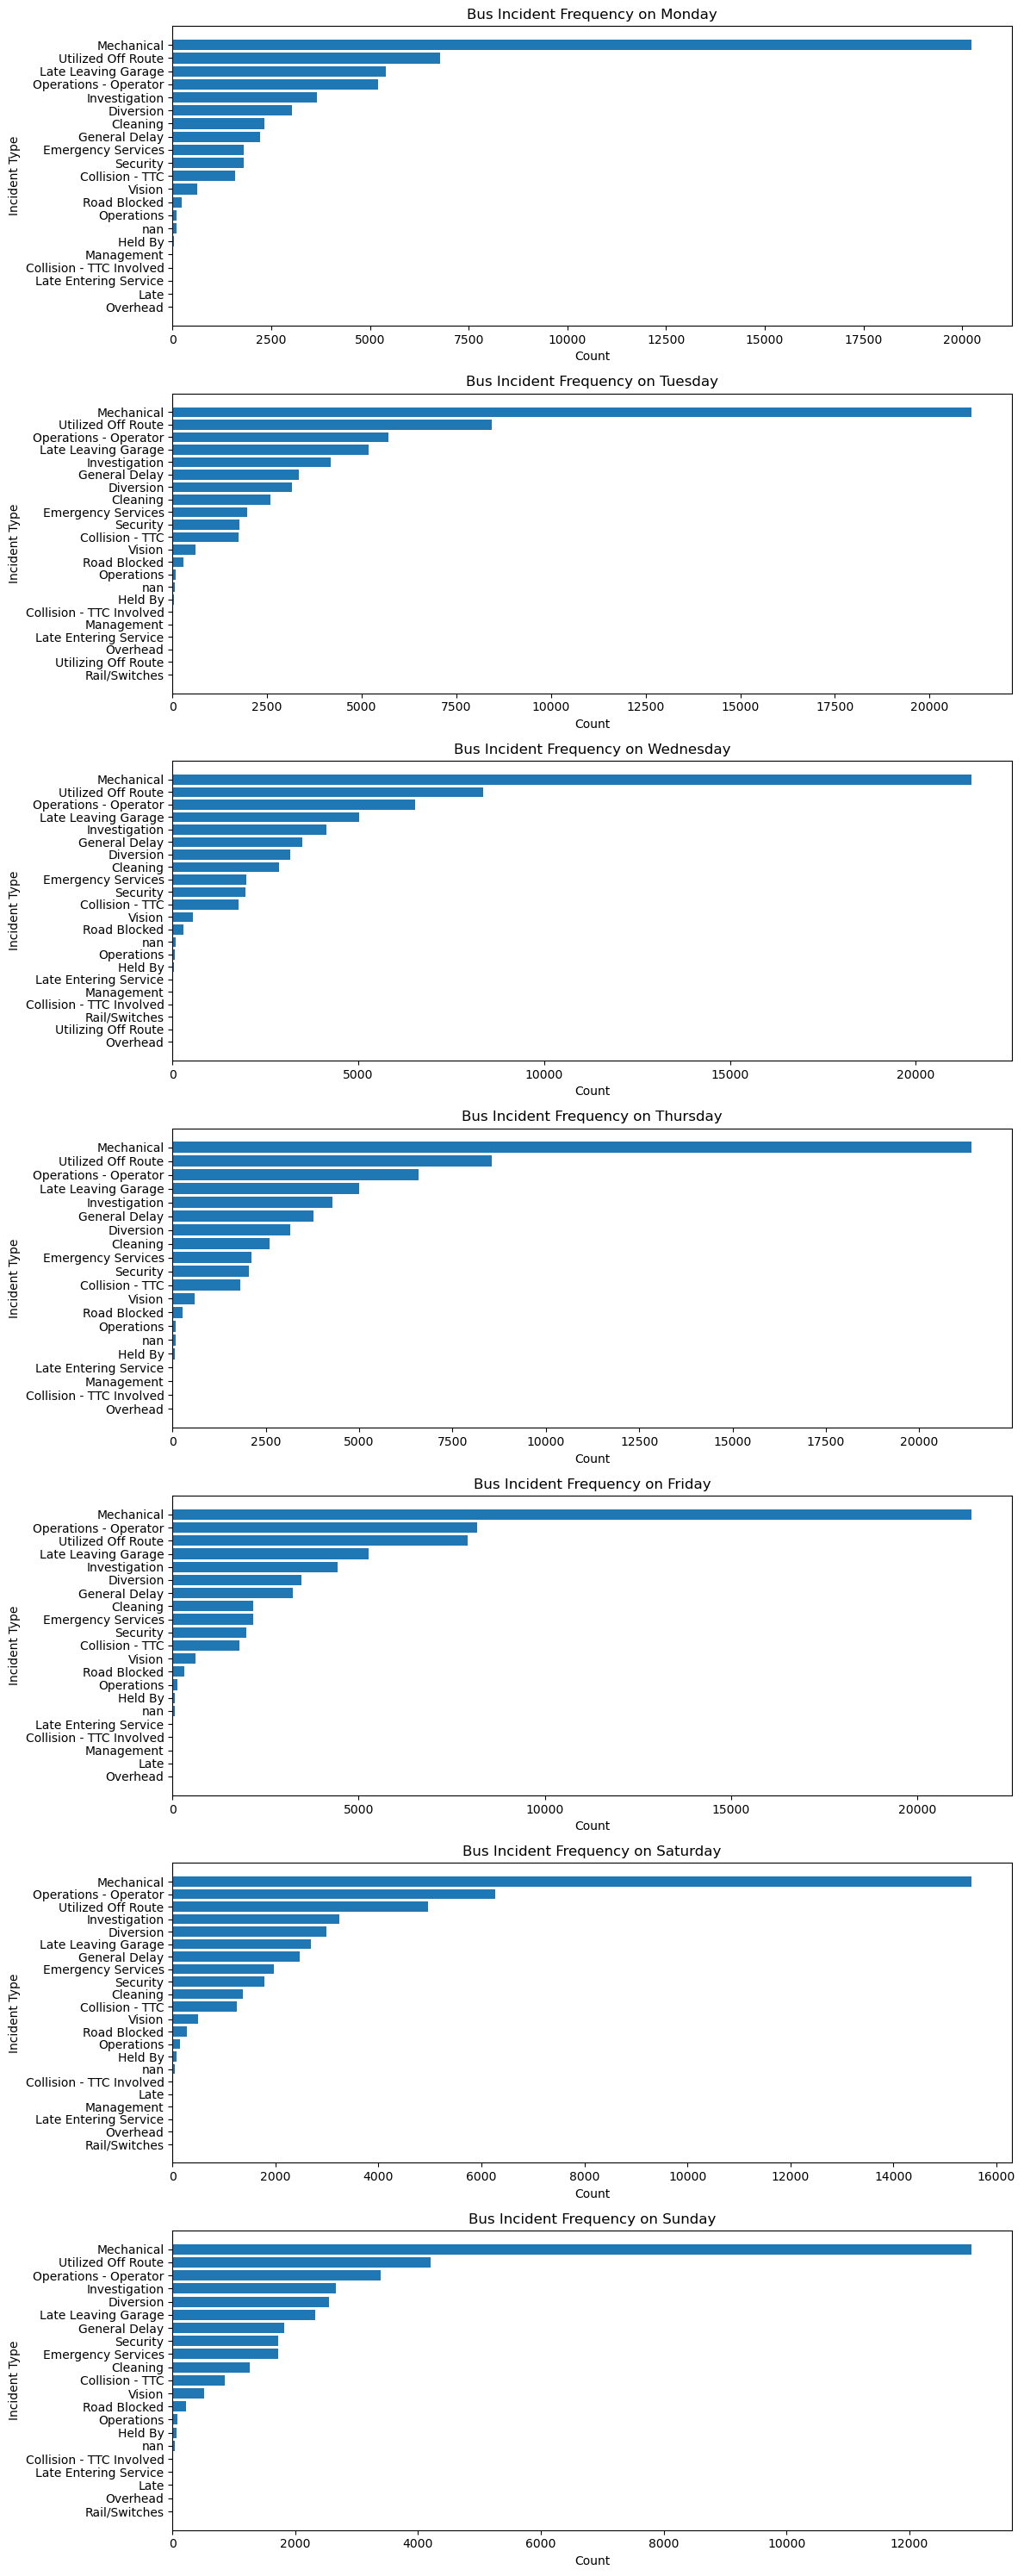

In [24]:
days_of_week = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

# Create a figure with 7 subplots (one for each day)
fig, axes = plt.subplots(7, 1, figsize=(12, 30))

# Loop through each day and plot a histogram
for i, day in enumerate(days_of_week):
    day_data = bus_data[bus_data["Day"] == day]
    incident_counts = day_data["Incident"].value_counts()

    axes[i].barh(incident_counts.index, incident_counts.values)
    axes[i].set_title(f"Bus Incident Frequency on {day}")
    axes[i].set_xlabel("Count")
    axes[i].set_ylabel("Incident Type")
    axes[i].invert_yaxis()  # Invert y-axis for better readability

plt.tight_layout()
plt.show()

In [25]:
import pandas as pd

# Days of the week in order
days_of_week = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

# Loop through each day and print the incident counts
for day in days_of_week:
    print(f"\n{day}")
    print("-" * len(day))
    
    # Filter data for the specific day
    day_data = bus_data[bus_data["Day"] == day]
    
    # Count occurrences of each incident type
    incident_counts = day_data["Incident"].value_counts()
    
    # Print the incidents and their counts
    total_count = incident_counts.sum()  # Compute total count for the day
    for incident, count in incident_counts.items():
        print(f"{incident}: {count}")
    
    # Print total frequency count for the day
    print(f"Total Incidents on {day}: {total_count}")



Monday
------
Mechanical: 20238
Utilized Off Route: 6768
Late Leaving Garage: 5398
Operations - Operator: 5197
Investigation: 3661
Diversion: 3017
Cleaning: 2327
General Delay: 2222
Emergency Services: 1808
Security: 1802
Collision - TTC: 1581
Vision: 620
Road Blocked: 240
Operations: 110
nan: 97
Held By: 43
Management: 8
Collision - TTC Involved: 6
Late Entering Service: 4
Late: 2
Overhead: 2
Total Incidents on Monday: 55151

Tuesday
-------
Mechanical: 21112
Utilized Off Route: 8434
Operations - Operator: 5700
Late Leaving Garage: 5178
Investigation: 4175
General Delay: 3340
Diversion: 3158
Cleaning: 2579
Emergency Services: 1980
Security: 1766
Collision - TTC: 1746
Vision: 604
Road Blocked: 300
Operations: 85
nan: 61
Held By: 43
Collision - TTC Involved: 8
Management: 7
Late Entering Service: 3
Overhead: 2
Utilizing Off Route: 1
Rail/Switches: 1
Total Incidents on Tuesday: 60283

Wednesday
---------
Mechanical: 21499
Utilized Off Route: 8364
Operations - Operator: 6525
Late Leaving

---

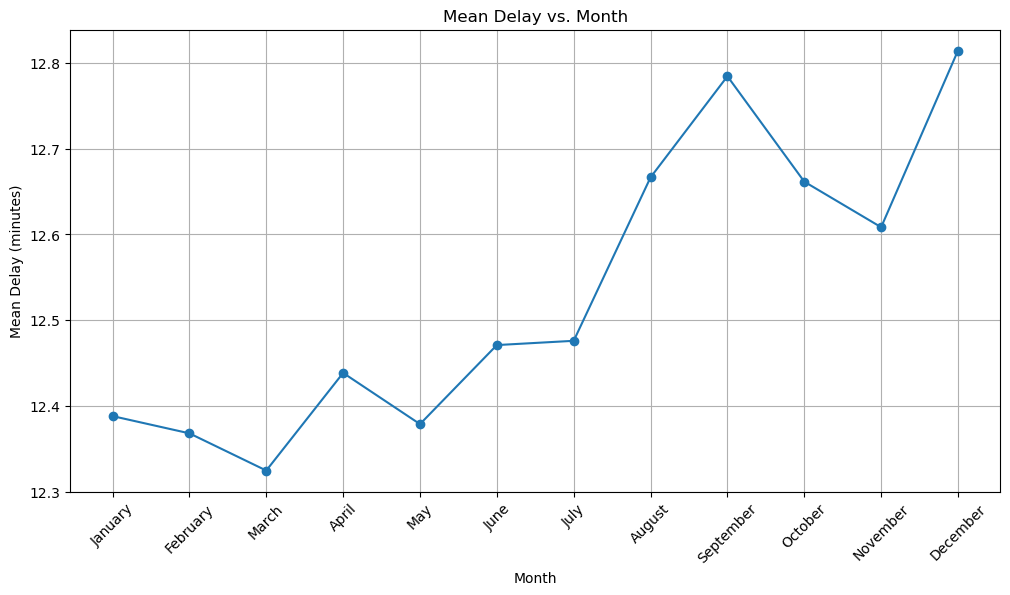

In [26]:
bus_data["DateTime"] = pd.to_datetime(bus_data["DateTime"])

# Extract month names for grouping
bus_data["Month"] = bus_data["DateTime"].dt.month_name()

# Drop outliers (same criteria as before)
bus_data_filtered = bus_data[bus_data["Min Delay"] <= 60]

# Compute mean delay per month
mean_bus_data_monthly = bus_data_filtered.groupby("Month")[["Min Delay"]].mean().reset_index()

# Define months in order
months_order = [
    "January", "February", "March", "April", "May", "June", 
    "July", "August", "September", "October", "November", "December"
]

# Reindex to ensure proper month order
mean_bus_data_monthly = mean_bus_data_monthly.set_index("Month").reindex(months_order).reset_index()

# Plot the mean delay vs. month
plt.figure(figsize=(12, 6))
plt.plot(mean_bus_data_monthly["Month"], mean_bus_data_monthly["Min Delay"], marker='o', linestyle='-')

# Formatting the graph
plt.xlabel("Month")
plt.ylabel("Mean Delay (minutes)")
plt.title("Mean Delay vs. Month")
plt.xticks(rotation=45)
plt.grid(True)

# Show plot
plt.show()


# By year 

In [27]:
bus_data["DateTime"] = pd.to_datetime(bus_data["DateTime"])

# Extract unique years from the dataset
unique_years = bus_data["DateTime"].dt.year.unique()

# Display unique years
print("Unique Years in the Dataset:", unique_years)

Unique Years in the Dataset: [2016 2133 2017 2134 2135 2018 2136 2137 2019 2138 2139 2020 2140 2141
 2021 2022 2023 2024]


/var/folders/xt/5my4_t657l5dvcsk9ybkb_ww0000gn/T/ipykernel_54664/2520122987.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bus_data_filtered["Year"] = bus_data_filtered["DateTime"].dt.year
/var/folders/xt/5my4_t657l5dvcsk9ybkb_ww0000gn/T/ipykernel_54664/2520122987.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bus_data_filtered["Month"] = bus_data_filtered["DateTime"].dt.month_name()


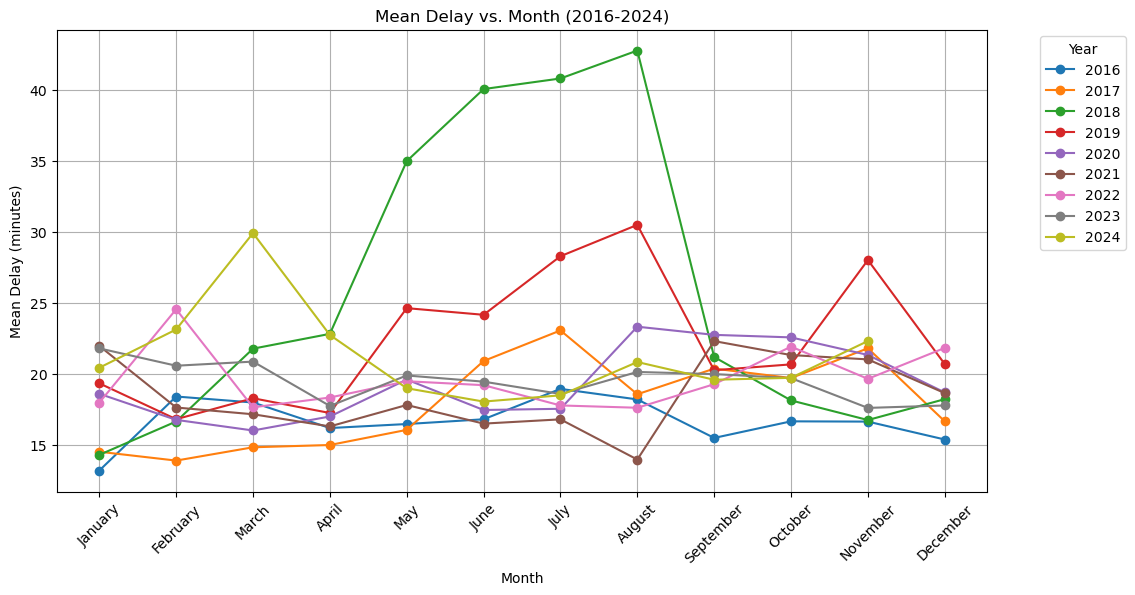

In [28]:
valid_years = list(range(2016, 2025))
bus_data_filtered = bus_data[bus_data["DateTime"].dt.year.isin(valid_years)]

# Extract month and year for grouping
bus_data_filtered["Year"] = bus_data_filtered["DateTime"].dt.year
bus_data_filtered["Month"] = bus_data_filtered["DateTime"].dt.month_name()

# Compute mean delay per month per year
mean_bus_data_monthly = bus_data_filtered.groupby(["Year", "Month"])[["Min Delay"]].mean().reset_index()

# Define months in order
months_order = [
    "January", "February", "March", "April", "May", "June", 
    "July", "August", "September", "October", "November", "December"
]

# Reindex to ensure proper month order
mean_bus_data_monthly["Month"] = pd.Categorical(mean_bus_data_monthly["Month"], categories=months_order, ordered=True)
mean_bus_data_monthly = mean_bus_data_monthly.sort_values(["Year", "Month"])

# Plot the mean delay vs. month for each year
plt.figure(figsize=(12, 6))

for year in valid_years:
    year_data = mean_bus_data_monthly[mean_bus_data_monthly["Year"] == year]
    plt.plot(year_data["Month"], year_data["Min Delay"], marker='o', linestyle='-', label=str(year))

# Formatting the graph
plt.xlabel("Month")
plt.ylabel("Mean Delay (minutes)")
plt.title("Mean Delay vs. Month (2016-2024)")
plt.xticks(rotation=45)
plt.legend(title="Year", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)

# Show plot
plt.show()
